In [1]:
# NB05: Swin-T Two-Stage ABMIL Training (PyTorch)
# Structure mirrors NB04 exactly (only backbone changes)
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import (
    f1_score, recall_score, roc_auc_score,
    roc_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"timm    : {timm.__version__}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128
CUDA    : True
timm    : 1.0.26
GPU     : Tesla T4


In [2]:
# Paths
NB02 = Path("/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction")
OUT  = Path("/kaggle/working")

X_TRAIN_PATH       = NB02 / "X_train_patches.npy"
Y_TRAIN_PATH       = NB02 / "y_train_labels.npy"
BAG_IDS_TRAIN_PATH = NB02 / "bag_ids_train.npy"
TRAIN_BAG_IDX_PATH = NB02 / "train_bag_indices.npy"
VAL_BAG_IDX_PATH   = NB02 / "val_bag_indices.npy"
CLASS_WEIGHTS_PATH = NB02 / "class_weights.json"
X_TEST_PATH        = NB02 / "X_test_patches.npy"
Y_TEST_PATH        = NB02 / "y_test_labels.npy"
BAG_IDS_TEST_PATH  = NB02 / "bag_ids_test.npy"

S1_WEIGHTS   = OUT / "swin_t_stage1.pth"
S2_WEIGHTS   = OUT / "swin_t_stage2.pth"
RESULTS_JSON = OUT / "swin_t_results.json"

print("NB02 path exists:", NB02.exists())

NB02 path exists: True


In [3]:
# Hyperparameters
MODEL_NAME = "swin_tiny_patch4_window7_224"
ATTN_DIM   = 128
PATCH_SIZE = 224
SEED       = 42

BS_STAGE1   = 128      # Maintained at 128 for strict structural cross-comparison
LR_STAGE1   = 1e-4     # Lower learning rate for transformer stability
EPOCHS_S1   = 25       # More epochs to compensate for the smaller step size
PATIENCE_S1 = 7        # More patience to give the lower LR timeto work

LR_S2_HEAD  = 1e-4
EPOCHS_S2   = 30
PATIENCE_S2 = 7

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


In [4]:
# Build backbone
def build_backbone(model_name, pretrained=True):
    return timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=0
    )

backbone = build_backbone(MODEL_NAME, pretrained=True).to(DEVICE)

with torch.no_grad():
    _dummy  = torch.zeros(2, 3, PATCH_SIZE, PATCH_SIZE, device=DEVICE)
    _out    = backbone(_dummy)
    FEAT_DIM = _out.shape[1]
    print(f"Backbone output shape : {_out.shape}")
    print(f"FEAT_DIM confirmed    : {FEAT_DIM}")
del _dummy, _out
print("Backbone verified.")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Backbone output shape : torch.Size([2, 768])
FEAT_DIM confirmed    : 768
Backbone verified.


In [5]:
# Load NB02 outputs
print("Loading arrays...")
X_train_all       = np.load(X_TRAIN_PATH)
y_train_all       = np.load(Y_TRAIN_PATH)
bag_ids_all       = np.load(BAG_IDS_TRAIN_PATH)
train_bag_indices = np.load(TRAIN_BAG_IDX_PATH)
val_bag_indices   = np.load(VAL_BAG_IDX_PATH)
X_test_all        = np.load(X_TEST_PATH)
y_test_all        = np.load(Y_TEST_PATH)
bag_ids_test      = np.load(BAG_IDS_TEST_PATH)

with open(CLASS_WEIGHTS_PATH) as f:
    raw_cw = json.load(f)
class_weight_dict = {int(k): float(v) for k, v in raw_cw.items()}

print(f"X_train_all : {X_train_all.shape}  dtype={X_train_all.dtype}")
print(f"benign={(y_train_all==0).sum()}  "
      f"malignant={(y_train_all==1).sum()}")
overlap = set(train_bag_indices) & set(val_bag_indices)
print(f"Patient overlap : {len(overlap)}  (must be 0)")
print(f"Class weights   : {class_weight_dict}")

Loading arrays...
X_train_all : (19770, 224, 224, 1)  dtype=float32
benign=13616  malignant=6154
Patient overlap : 0  (must be 0)
Class weights   : {0: 0.7259841363102233, 1: 1.6062723431914203}


In [6]:
# Split patches
train_mask = np.isin(bag_ids_all, train_bag_indices)
val_mask   = np.isin(bag_ids_all, val_bag_indices)

X_tr    = X_train_all[train_mask];  y_tr  = y_train_all[train_mask]
bag_tr  = bag_ids_all[train_mask]
X_val   = X_train_all[val_mask];    y_val = y_train_all[val_mask]
bag_val = bag_ids_all[val_mask]

print(f"Train patches : {X_tr.shape}  "
      f"benign={(y_tr==0).sum()}  malignant={(y_tr==1).sum()}")
print(f"Val patches   : {X_val.shape}  "
      f"benign={(y_val==0).sum()}  malignant={(y_val==1).sum()}")

Train patches : (16198, 224, 224, 1)  benign=11356  malignant=4842
Val patches   : (3572, 224, 224, 1)  benign=2260  malignant=1312


In [8]:
# Normalisation tensors
# _mean_cpu = torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(3,1,1)
# _std_cpu  = torch.tensor(IMAGENET_STD,  dtype=torch.float32).view(3,1,1)
_mean_gpu = torch.tensor(IMAGENET_MEAN, dtype=torch.float32,device=DEVICE).view(1,3,1,1)
_std_gpu  = torch.tensor(IMAGENET_STD,  dtype=torch.float32,device=DEVICE).view(1,3,1,1)

# def numpy_to_tensor(X_np):
#     t = torch.from_numpy(X_np).float()
#     t = t.permute(0, 3, 1, 2).repeat(1, 3, 1, 1).to(DEVICE)
#     return (t - _mean_gpu) / _std_gpu

In [9]:
# Datasets (identical to NB04)
class PatchDataset(Dataset):
    def __init__(self, X_np, y_np):
        self.X = X_np
        self.y = torch.from_numpy(y_np).float()

    def __len__(self):
        return len(self.y)

    # def __getitem__(self, idx):
    #     patch = torch.from_numpy(self.X[idx]).float()
    #     patch = patch.permute(2, 0, 1).repeat(3, 1, 1)
    #     patch = (patch - _mean_cpu) / _std_cpu
    #     return patch, self.y[idx]

    def __getitem__(self, idx):
        patch = torch.from_numpy(self.X[idx]).float()
        return patch.permute(2, 0, 1), self.y[idx]


class CachedBagDataset(Dataset):
    def __init__(self, features, y_np, bag_ids, bag_list):
        self.features = features
        self.y        = y_np
        self.bag_ids  = bag_ids
        self.bag_list = bag_list

    def __len__(self):
        return len(self.bag_list)

    def __getitem__(self, idx):
        bid  = self.bag_list[idx]
        mask = self.bag_ids == bid
        h    = torch.from_numpy(self.features[mask]).float()
        bag_label = torch.tensor(self.y[mask][0], dtype=torch.float32)
        return h, bag_label


def collate_cached(batch):
    return ([item[0] for item in batch],
            torch.stack([item[1] for item in batch]))

In [10]:
# Model components (identical to NB04)
class PatchClassifier(nn.Module):
    def __init__(self, backbone, feat_dim):
        super().__init__()
        self.backbone = backbone
        self.head     = nn.Linear(feat_dim, 1)

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)


class AttentionPool(nn.Module):
    def __init__(self, feat_dim, attn_dim):
        super().__init__()
        self.V = nn.Linear(feat_dim, attn_dim, bias=True)
        self.w = nn.Linear(attn_dim, 1,        bias=False)

    def forward(self, h):
        a = torch.softmax(self.w(torch.tanh(self.V(h))), dim=0)
        z = torch.sum(a * h, dim=0, keepdim=True)
        return z, a


class BagClassifier(nn.Module):
    def __init__(self, feat_dim, attn_dim):
        super().__init__()
        self.attn = AttentionPool(feat_dim, attn_dim)
        self.head = nn.Linear(feat_dim, 1)

    def forward(self, h):
        z, a = self.attn(h)
        return self.head(z).squeeze(), a

In [11]:
# Stage 1 setup
# patch_model = PatchClassifier(backbone, FEAT_DIM).to(DEVICE)

# pos_weight_val = class_weight_dict[1] / class_weight_dict[0]
# criterion_s1   = nn.BCEWithLogitsLoss(
#     pos_weight=torch.tensor(pos_weight_val, device=DEVICE)
# )
# print(f"pos_weight : {pos_weight_val:.4f}")

# optimiser_s1 = optim.Adam(patch_model.parameters(), lr=LR_STAGE1)
# scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
#     optimiser_s1, mode='min', factor=0.5, patience=3
# )

# train_patch_dl = DataLoader(
#     PatchDataset(X_tr, y_tr),
#     batch_size=BS_STAGE1, shuffle=True,
#     num_workers=2, pin_memory=True
# )
# val_patch_dl = DataLoader(
#     PatchDataset(X_val, y_val),
#     batch_size=BS_STAGE1, shuffle=False,
#     num_workers=2, pin_memory=True
# )
# print(f"Train batches : {len(train_patch_dl)}")
# print(f"Val batches   : {len(val_patch_dl)}")

patch_model = PatchClassifier(backbone, FEAT_DIM).to(DEVICE)

pos_weight_val = class_weight_dict[1] / class_weight_dict[0]
criterion_s1   = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_val, device=DEVICE))

# Upgraded to AdamW to safely process Transformer weight-decay computations
optimiser_s1 = optim.AdamW(patch_model.parameters(), lr=LR_STAGE1, weight_decay=1e-2)
scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(optimiser_s1, mode='min', factor=0.5, patience=3)

train_patch_dl = DataLoader(PatchDataset(X_tr, y_tr), batch_size=BS_STAGE1, shuffle=True, num_workers=2, pin_memory=True)
val_patch_dl   = DataLoader(PatchDataset(X_val, y_val), batch_size=BS_STAGE1, shuffle=False, num_workers=2, pin_memory=True)

In [12]:
# # Stage 1 training loop (GPU-accelerated)
# s1_history = {"train_loss": [], "val_loss": [],
#               "val_auc": [],    "val_f1":  []}
# best_val_loss_s1    = float("inf")
# patience_counter_s1 = 0
# t0 = time.time()

# for epoch in range(1, EPOCHS_S1 + 1):
#     patch_model.train()
#     running_loss = 0.0
#     for patches, labels in train_patch_dl:
#         patches, labels = patches.to(DEVICE), labels.to(DEVICE)
#         optimiser_s1.zero_grad()
#         loss = criterion_s1(patch_model(patches), labels)
#         loss.backward()
#         optimiser_s1.step()
#         running_loss += loss.item() * len(labels)
#     train_loss = running_loss / len(train_patch_dl.dataset)

#     patch_model.eval()
#     val_loss, all_probs, all_labels = 0.0, [], []
#     with torch.no_grad():
#         for patches, labels in val_patch_dl:
#             patches, labels = patches.to(DEVICE), labels.to(DEVICE)
#             logits   = patch_model(patches)
#             val_loss += criterion_s1(logits, labels).item() * len(labels)
#             all_probs.extend(torch.sigmoid(logits).cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
#     val_loss  /= len(val_patch_dl.dataset)
#     all_probs  = np.array(all_probs)
#     all_labels = np.array(all_labels)
#     val_preds  = (all_probs >= 0.5).astype(int)
#     val_auc    = roc_auc_score(all_labels, all_probs)
#     val_f1     = f1_score(all_labels, val_preds, zero_division=0)

#     s1_history["train_loss"].append(train_loss)
#     s1_history["val_loss"].append(val_loss)
#     s1_history["val_auc"].append(val_auc)
#     s1_history["val_f1"].append(val_f1)
#     scheduler_s1.step(val_loss)

#     print(f"Ep {epoch:02d}/{EPOCHS_S1}  "
#           f"train={train_loss:.4f}  val={val_loss:.4f}  "
#           f"auc={val_auc:.4f}  f1={val_f1:.4f}")

#     if val_loss < best_val_loss_s1:
#         best_val_loss_s1    = val_loss
#         patience_counter_s1 = 0
#         torch.save(patch_model.state_dict(), S1_WEIGHTS)
#         print("  ✓ Saved best Stage 1 weights")
#     else:
#         patience_counter_s1 += 1
#         if patience_counter_s1 >= PATIENCE_S1:
#             print(f"  Early stopping at epoch {epoch}")
#             break

# print(f"\nStage 1 complete — {(time.time()-t0)/60:.1f} min")

scaler = torch.amp.GradScaler('cuda')

s1_history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
best_val_loss_s1    = float("inf")
patience_counter_s1 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S1 + 1):
    patch_model.train()
    running_loss = 0.0
    for patches, labels in train_patch_dl:
        patches, labels = patches.to(DEVICE), labels.to(DEVICE)
        
        # Super-speed batched transformation on GPU tensor cores
        patches = patches.repeat(1, 3, 1, 1)
        patches = (patches - _mean_gpu) / _std_gpu
        
        optimiser_s1.zero_grad()
        
        with torch.amp.autocast('cuda'):
            logits = patch_model(patches)
            loss = criterion_s1(logits, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimiser_s1)
        scaler.update()
        
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_patch_dl.dataset)

    patch_model.eval()
    val_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for patches, labels in val_patch_dl:
            patches, labels = patches.to(DEVICE), labels.to(DEVICE)
            
            patches = patches.repeat(1, 3, 1, 1)
            patches = (patches - _mean_gpu) / _std_gpu
            
            with torch.amp.autocast('cuda'):
                logits   = patch_model(patches)
                loss_val = criterion_s1(logits, labels)
                
            val_loss += loss_val.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_loss  /= len(val_patch_dl.dataset)
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    val_preds  = (all_probs >= 0.5).astype(int)
    val_auc    = roc_auc_score(all_labels, all_probs)
    val_f1     = f1_score(all_labels, val_preds, zero_division=0)

    s1_history["train_loss"].append(train_loss)
    s1_history["val_loss"].append(val_loss)
    s1_history["val_auc"].append(val_auc)
    s1_history["val_f1"].append(val_f1)
    scheduler_s1.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S1}  train={train_loss:.4f}  val={val_loss:.4f}  auc={val_auc:.4f}  f1={val_f1:.4f}")

    if val_loss < best_val_loss_s1:
        best_val_loss_s1    = val_loss
        patience_counter_s1 = 0
        torch.save(patch_model.state_dict(), S1_WEIGHTS)
        print("  ✓ Saved best Stage 1 weights")
    else:
        patience_counter_s1 += 1
        if patience_counter_s1 >= PATIENCE_S1:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 1 complete — {(time.time()-t0)/60:.1f} min")

Ep 01/25  train=0.6811  val=0.7050  auc=0.7940  f1=0.6688
  ✓ Saved best Stage 1 weights
Ep 02/25  train=0.6277  val=0.7035  auc=0.8087  f1=0.6615
  ✓ Saved best Stage 1 weights
Ep 03/25  train=0.6003  val=0.7222  auc=0.8208  f1=0.6850
Ep 04/25  train=0.5859  val=0.7283  auc=0.8110  f1=0.6884
Ep 05/25  train=0.5531  val=0.7145  auc=0.8146  f1=0.6613
Ep 06/25  train=0.5124  val=0.7889  auc=0.8088  f1=0.6659
Ep 07/25  train=0.3934  val=0.8990  auc=0.8015  f1=0.6592
Ep 08/25  train=0.3149  val=1.0356  auc=0.8063  f1=0.6649
Ep 09/25  train=0.2598  val=1.2187  auc=0.7968  f1=0.6488
  Early stopping at epoch 9

Stage 1 complete — 15.0 min


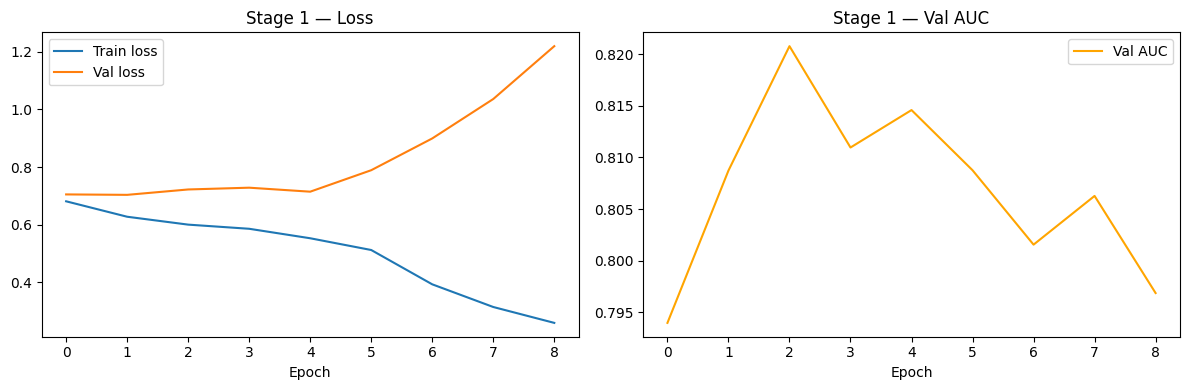

Saved swin_t_stage1_curves.png


In [13]:
# Stage 1 curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s1_history["train_loss"], label="Train loss")
axes[0].plot(s1_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 1 — Loss");     axes[0].legend()
axes[0].set_xlabel("Epoch")
axes[1].plot(s1_history["val_auc"], color="orange", label="Val AUC")
axes[1].set_title("Stage 1 — Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(OUT / "swin_t_stage1_curves.png", dpi=150)
plt.show()
print("Saved swin_t_stage1_curves.png")

In [14]:
# # Stage 1 patch-level diagnostic metrics
# patch_model.load_state_dict(
#     torch.load(S1_WEIGHTS, map_location=DEVICE))
# patch_model.eval()

# all_probs, all_labels = [], []
# with torch.no_grad():
#     for patches, labels in val_patch_dl:
#         patches = patches.to(DEVICE)
#         all_probs.extend(
#             torch.sigmoid(patch_model(patches)).cpu().numpy())
#         all_labels.extend(labels.numpy())

# all_probs  = np.array(all_probs)
# all_labels = np.array(all_labels)
# preds      = (all_probs >= 0.5).astype(int)
# tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

# s1_metrics = {
#     "patch_auc"        : float(roc_auc_score(all_labels, all_probs)),
#     "patch_f1"         : float(f1_score(all_labels, preds,
#                                          zero_division=0)),
#     "patch_sensitivity": float(recall_score(all_labels, preds,
#                                              zero_division=0)),
#     "patch_specificity": float(tn / (tn + fp)),
# }
# print("── Stage 1 Patch-Level Val Metrics ──")
# for k, v in s1_metrics.items():
#     print(f"  {k:25s}: {v:.4f}")

patch_model.load_state_dict(torch.load(S1_WEIGHTS, map_location=DEVICE))
patch_model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for patches, labels in val_patch_dl:
        patches = patches.to(DEVICE)
        patches = patches.repeat(1, 3, 1, 1)
        patches = (patches - _mean_gpu) / _std_gpu
        
        with torch.amp.autocast('cuda'):
            all_probs.extend(torch.sigmoid(patch_model(patches)).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

s1_metrics = {
    "patch_auc"        : float(roc_auc_score(all_labels, all_probs)),
    "patch_f1"         : float(f1_score(all_labels, preds, zero_division=0)),
    "patch_sensitivity": float(recall_score(all_labels, preds, zero_division=0)),
    "patch_specificity": float(tn / (tn + fp)),
}
print("── Stage 1 Patch-Level Val Metrics ──")
for k, v in s1_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

── Stage 1 Patch-Level Val Metrics ──
  patch_auc                : 0.8087
  patch_f1                 : 0.6615
  patch_sensitivity        : 0.6494
  patch_specificity        : 0.8177


In [16]:
# # Feature extraction
# feature_extractor = patch_model.backbone
# feature_extractor.eval()
# for p in feature_extractor.parameters():
#     p.requires_grad_(False)

# def extract_features(X_np, model, batch_size=128):
#     # Swin-T uses batch_size=128 here rather than 256
#     # because it is heavier — increase if no OOM
#     all_feats = []
#     model.eval()
#     with torch.no_grad():
#         for start in range(0, len(X_np), batch_size):
#             t     = numpy_to_tensor(X_np[start:start+batch_size])
#             feats = model(t).cpu().numpy()
#             all_feats.append(feats)
#     return np.concatenate(all_feats, axis=0)

# print("Extracting train features...")
# feats_tr   = extract_features(X_tr,       feature_extractor)
# print(f"  train : {feats_tr.shape}")

# print("Extracting val features...")
# feats_val  = extract_features(X_val,      feature_extractor)
# print(f"  val   : {feats_val.shape}")

# print("Extracting test features...")
# feats_test = extract_features(X_test_all, feature_extractor)
# print(f"  test  : {feats_test.shape}")

# Feature extraction
feature_extractor = patch_model.backbone
feature_extractor.eval()
for p in feature_extractor.parameters():
    p.requires_grad_(False)

def extract_features(X_np, model, batch_size=256):
    all_feats = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(X_np), batch_size):
            # 1. Slice and convert the raw batch to a tensor on CPU
            batch_np = X_np[start : start + batch_size]
            t = torch.from_numpy(batch_np).float()             # Shape: (BS, 224, 224, 1)
            
            # 2. Push to GPU and change shape to channels-first
            t = t.permute(0, 3, 1, 2).to(DEVICE)               # Shape: (BS, 1, 224, 224)
            
            # 3. Vectorized GPU broadcasting math (Replaces numpy_to_tensor)
            t = t.repeat(1, 3, 1, 1)                           # Shape: (BS, 3, 224, 224)
            t = (t - _mean_gpu) / _std_gpu                     # High-speed normalization
            
            # 4. Extract and cache features via unified autocast
            with torch.amp.autocast('cuda'):
                feats = model(t).cpu().numpy()
            all_feats.append(feats)
            
    return np.concatenate(all_feats, axis=0)

print("Extracting train features...")
feats_tr   = extract_features(X_tr,       feature_extractor)
print(f"  train : {feats_tr.shape}")

print("Extracting val features...")
feats_val  = extract_features(X_val,      feature_extractor)
print(f"  val   : {feats_val.shape}")

print("Extracting test features...")
feats_test = extract_features(X_test_all, feature_extractor)
print(f"  test  : {feats_test.shape}")

Extracting train features...
  train : (16198, 768)
Extracting val features...
  val   : (3572, 768)
Extracting test features...
  test  : (5997, 768)
